# LOINC Crosswalk — Error Analysis

This notebook runs the full error analysis pipeline from `src/error_analysis.py` on both the best TF-IDF configuration and the best Sentence Transformer configuration.

**Best configs:**
- TF-IDF: `lcn_method_dict_combined` corpus, `tfidf_word`, ngram `(1,1)` — pre-run results in `filter_ablation.csv` (no-filter condition)
- ST: `pritamdeka/S-PubMedBert-MS-MARCO`, `regular_corpus` — results in `sentence_transformer_ablation_results.csv`

**Sections:**
1. Setup & data loading
2. Filter ablation: no-filter vs oracle vs brand (TF-IDF best config)
3. Single-model error analysis — TF-IDF
4. Single-model error analysis — ST (PubMedBERT)
5. Cross-model comparison: coverage pattern and noise dimensions
6. Noise component MRR profiles
7. Noise audit: component-presence heatmaps

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import os
import sys

# Get the repo root — works whether notebook is in root or notebooks/ folder
notebook_dir = Path(os.getcwd())
repo_root = notebook_dir if (notebook_dir / 'src').exists() else notebook_dir.parent

sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

from src.clinical_utils import clean_text
from src.model_building_utils import (
    expand_loinc_lcn,
    normalize_elr,
    compute_relatednames_stopwords,
    GENE_TARGET_AMBIGUITY_LOOKUP,
    CATCHALL_COVERAGE,
)
from src.error_analysis import (
    classify_axis_mismatches,
    classify_system_direction,
    system_direction_summary,
    axis_mismatch_by_coverage,
    axis_mismatch_by_strategy,
    summarize_by_noise,
    plot_noise_mrr_profile,
    plot_model_comparison_by_coverage,
    plot_model_comparison_by_noise,
    plot_error_analysis,
    run_error_analysis,
    run_noise_analysis,
    run_model_comparison,
    COVERAGE_ORDER,
    NOISE_LEVEL_ORDER,
    NOISE_COLS,
)
from src.ablation import summarize_filter_ablation, brand_recovery_fraction

sns.set_theme(style="whitegrid", font_scale=1.0)
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
# ---------------------------------------------------------------------------
# Load LOINC reference
# ---------------------------------------------------------------------------
loinc = pd.read_csv("data/processed/covid_surveillance_loinc.csv")
loinc = loinc[~loinc["method_typ"].isna()].copy()
loinc["expanded_lcn"] = loinc["long_common_name"].map(clean_text).map(expand_loinc_lcn)

print(f"LOINC reference: {loinc.shape[0]} rows, {loinc['loinc_num'].nunique()} unique codes")

LOINC reference: 98 rows, 98 unique codes


In [3]:
# ---------------------------------------------------------------------------
# Load filter ablation results (TF-IDF best config, all three filter conditions)
# ---------------------------------------------------------------------------
df_filter_raw = pd.read_csv("data/results/filter_ablation.csv")

# Separate the three conditions
df_tfidf_best = df_filter_raw[df_filter_raw["filter_condition"] == "no_filter"].copy()
df_oracle     = df_filter_raw[df_filter_raw["filter_condition"] == "oracle_filter"].copy()
df_brand      = df_filter_raw[df_filter_raw["filter_condition"] == "brand_filter"].copy()

print(f"Filter ablation rows: {df_filter_raw.shape[0]:,}")
print(f"  no_filter:     {len(df_tfidf_best):,}")
print(f"  oracle_filter: {len(df_oracle):,}")
print(f"  brand_filter:  {len(df_brand):,}")

Filter ablation rows: 15,840
  no_filter:     5,280
  oracle_filter: 5,280
  brand_filter:  5,280


In [4]:
# ---------------------------------------------------------------------------
# Load Sentence Transformer results — best model on regular corpus
# ---------------------------------------------------------------------------
BEST_ST_MODEL = "pritamdeka/S-PubMedBert-MS-MARCO"

st_all = pd.read_csv("data/results/sentence_transformer_ablation_results.csv")
df_st_best = st_all[
    (st_all["model_type"] == BEST_ST_MODEL) &
    (st_all["strategy"] == "regular_corpus")
].copy()

print(f"ST best config rows: {len(df_st_best):,}")
print(f"Mean grouped MRR (ST): {df_st_best['mrr_grouped'].mean():.4f}")
print(f"Mean grouped MRR (TF-IDF best): {df_tfidf_best['mrr_grouped'].mean():.4f}")

ST best config rows: 5,280
Mean grouped MRR (ST): 0.6170
Mean grouped MRR (TF-IDF best): 0.7474


## 2. Filter Ablation: No-Filter vs Oracle vs Brand

In [5]:
# Simple summary
df_filter_raw.groupby(["filter_condition"]).agg(mrr_grouped=("mrr_grouped", "mean"),top1=("top1", "mean"),n=("mrr_grouped", "count"),).reset_index()

,filter_condition,mrr_grouped,top1,n
0,brand_filter,0.747585,0.282197,5280
1,no_filter,0.747443,0.282008,5280
2,oracle_filter,0.766569,0.293182,5280


In [6]:
# Overall summary table
filter_summary = summarize_filter_ablation(df_filter_raw)
print("Filter ablation summary (grouped MRR by condition, coverage pattern, has_method):")
print(filter_summary.sort_values(["filter_condition", "has_method"]).head(40))

Filter ablation summary (grouped MRR by condition, coverage pattern, has_method):
   filter_condition coverage_pattern  has_method  mrr_grouped      top1     n
0      brand_filter                A           0     0.744509  0.312709   598
2      brand_filter              A+I           0     0.647163  0.276596    94
4      brand_filter              A+M           0     0.761574  0.291667    72
6      brand_filter            A+M+I           0     0.694444  0.333333    12
8      brand_filter            A+M+S           0     0.472868  0.139535    43
10     brand_filter          A+M+S+I           0     1.000000  0.000000     1
12     brand_filter              A+S           0     0.737103  0.166667   252
14     brand_filter            A+S+I           0     0.680208  0.083333    48
16     brand_filter                I           0     0.111111  0.111111     9
18     brand_filter                M           0     0.750000  0.333333     3
20     brand_filter              M+I           0     0.33333

In [7]:
# has_method=0 sub-table — the primary target population for the filters
print("has_method=0 population (primary filter target):")
filter_summary[filter_summary["has_method"] == 0].sort_values(
    ["filter_condition", "coverage_pattern"]
)

has_method=0 population (primary filter target):


,filter_condition,coverage_pattern,has_method,mrr_grouped,top1,n
0,brand_filter,A,0,0.744509,0.312709,598
2,brand_filter,A+I,0,0.647163,0.276596,94
4,brand_filter,A+M,0,0.761574,0.291667,72
6,brand_filter,A+M+I,0,0.694444,0.333333,12
8,brand_filter,A+M+S,0,0.472868,0.139535,43
10,brand_filter,A+M+S+I,0,1.000000,0.000000,1
12,brand_filter,A+S,0,0.737103,0.166667,252
14,brand_filter,A+S+I,0,0.680208,0.083333,48
16,brand_filter,I,0,0.111111,0.111111,9
18,brand_filter,M,0,0.750000,0.333333,3


In [8]:
# Brand recovery fraction — has_model=1 population only
print("Brand filter recovery fraction (has_model=1):")
brand_recovery_fraction(df_filter_raw)

Brand filter recovery fraction (has_model=1):


filter_condition,brand_filter,no_filter,oracle_filter,brand_recovery_pct
coverage_pattern,,,,
A,0.788869,0.788869,0.791302,0.0
A+I,0.661765,0.661765,0.661765,NaN
A+M,0.816092,0.816092,0.821839,0.0
A+M+I,0.733333,0.733333,0.733333,NaN
I,0.000000,0.000000,0.000000,NaN
M,0.625000,0.625000,0.666667,0.0
NONE,0.477273,0.477273,0.477273,NaN


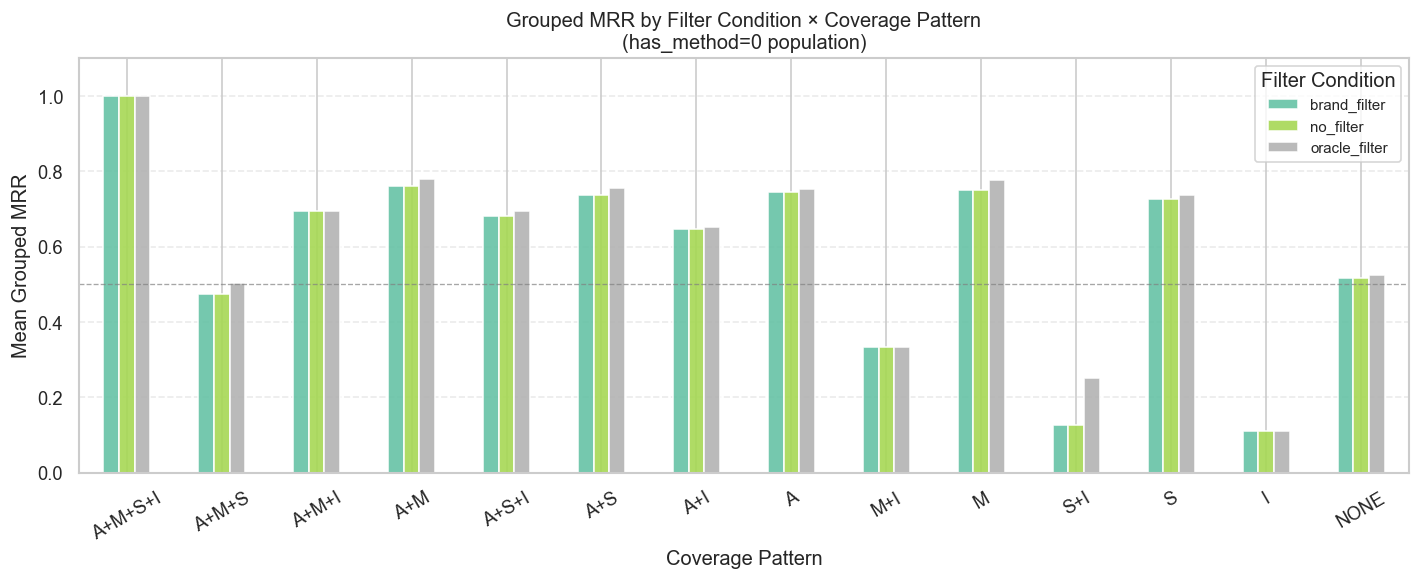

In [9]:
# -----------------------------------------------------------------------
# Visualize: grouped MRR by filter condition × coverage pattern (has_method=0)
# -----------------------------------------------------------------------

pop_no_meth = df_filter_raw[df_filter_raw["has_method"] == 0].copy()

pivot = (
    pop_no_meth
    .groupby(["filter_condition", "coverage_pattern"])["mrr_grouped"]
    .mean()
    .unstack("filter_condition")
    .reindex([p for p in COVERAGE_ORDER if p in pop_no_meth["coverage_pattern"].unique()])
)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", alpha=0.9)
ax.set_title("Grouped MRR by Filter Condition × Coverage Pattern\n(has_method=0 population)", fontsize=12)
ax.set_xlabel("Coverage Pattern")
ax.set_ylabel("Mean Grouped MRR")
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
ax.legend(title="Filter Condition", fontsize=9)
ax.tick_params(axis="x", rotation=30)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("data/results/viz_filter_ablation_has_method0.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Single-Model Error Analysis — TF-IDF (Best Configuration)

In [10]:
# Classify axis mismatches for TF-IDF
df_tfidf_classified = classify_axis_mismatches(df_tfidf_best, loinc)

print("System direction summary (TF-IDF, wrong top-1 predictions):")
display(system_direction_summary(df_tfidf_classified))

System direction summary (TF-IDF, wrong top-1 predictions):


mrr_correct,mrr_grouped<1 (real error),mrr_grouped=1 (absorbed)
direction_system,,
catchall_to_specific,595,677
same,820,903
specific_to_catchall,68,246
specific_to_specific,172,310


In [11]:
print("Axis mismatch rate by coverage pattern (percentage of all rows):")
display(axis_mismatch_by_coverage(df_tfidf_classified))

Axis mismatch rate by coverage pattern (percentage of all rows):


,Component,Method,System
coverage_pattern,,,
A+M+S+I,17.333333,18.666667,30.000000
A+M+S,22.156197,17.402377,27.079796
A+M+I,15.030675,15.337423,18.711656
A+M,21.153846,13.141026,26.144689
A+S+I,15.384615,38.461538,32.692308
A+S,21.771218,24.354244,24.723247
A+I,28.037383,31.775701,15.887850
A,24.074074,18.364198,25.154321
M+S+I,29.411765,17.647059,17.647059


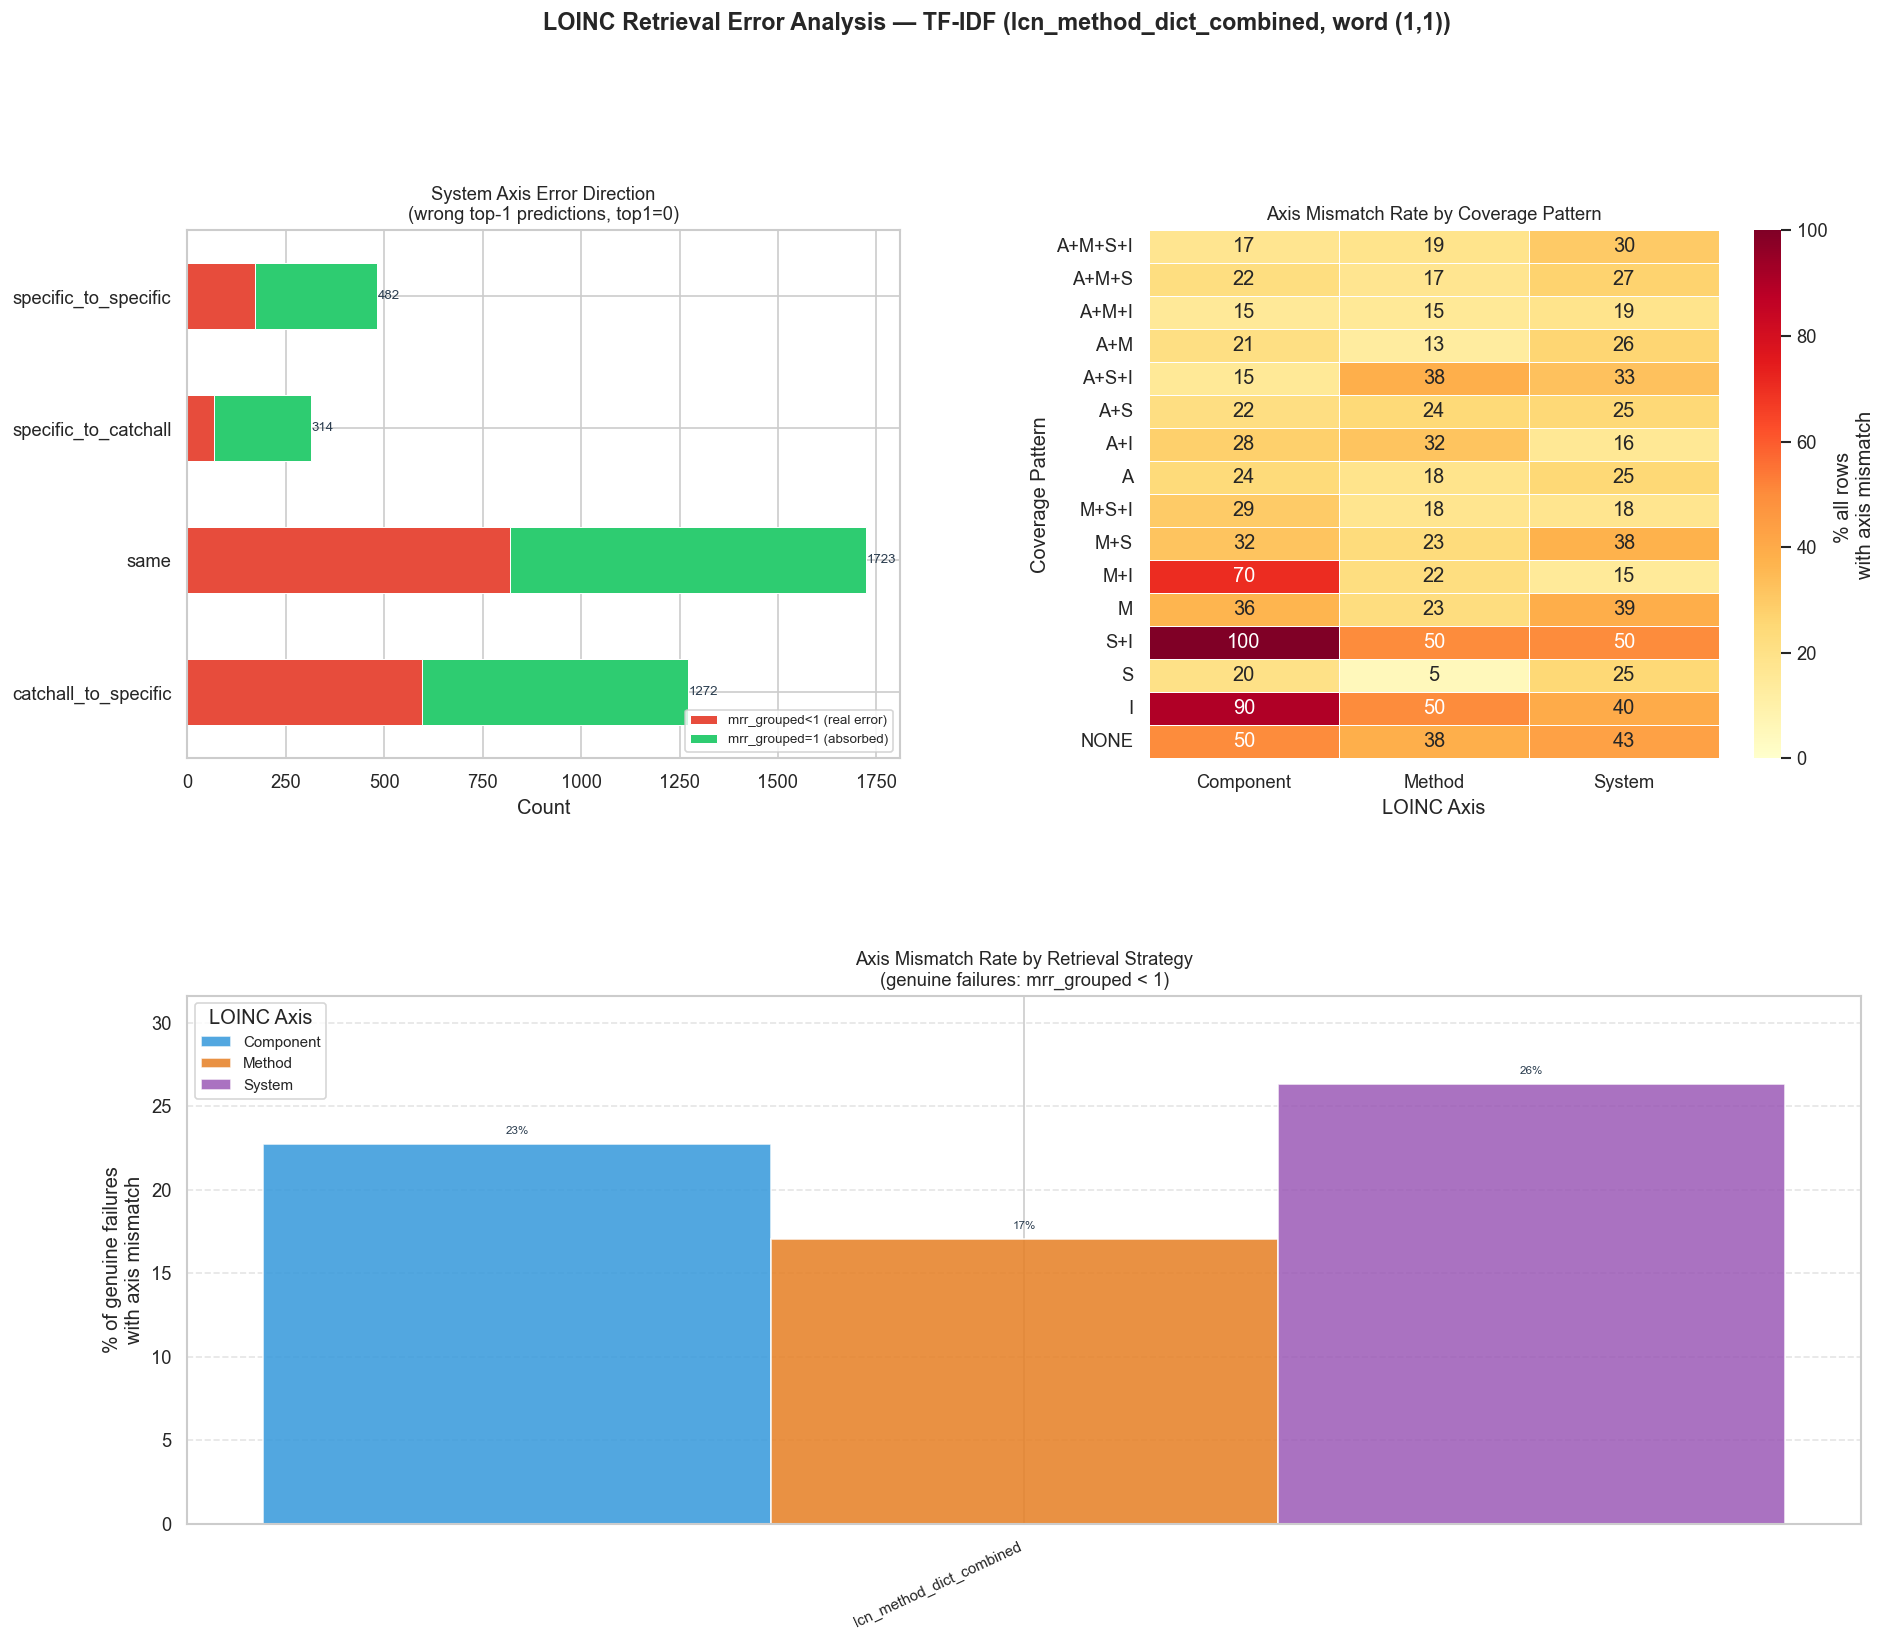

In [12]:
# Three-panel error analysis figure
# Note: strategy_col is not meaningful here (single config) — Panel 3 will show one bar.
# For multi-strategy comparisons, load primary ablation results instead.
fig_ea_tfidf = run_error_analysis(
    df_tfidf_best,
    loinc,
    strategy_col="corpus_strategy",
    title_suffix="— TF-IDF (lcn_method_dict_combined, word (1,1))",
    save_path="data/results/viz_error_analysis_tfidf.png",
)
display(fig_ea_tfidf)

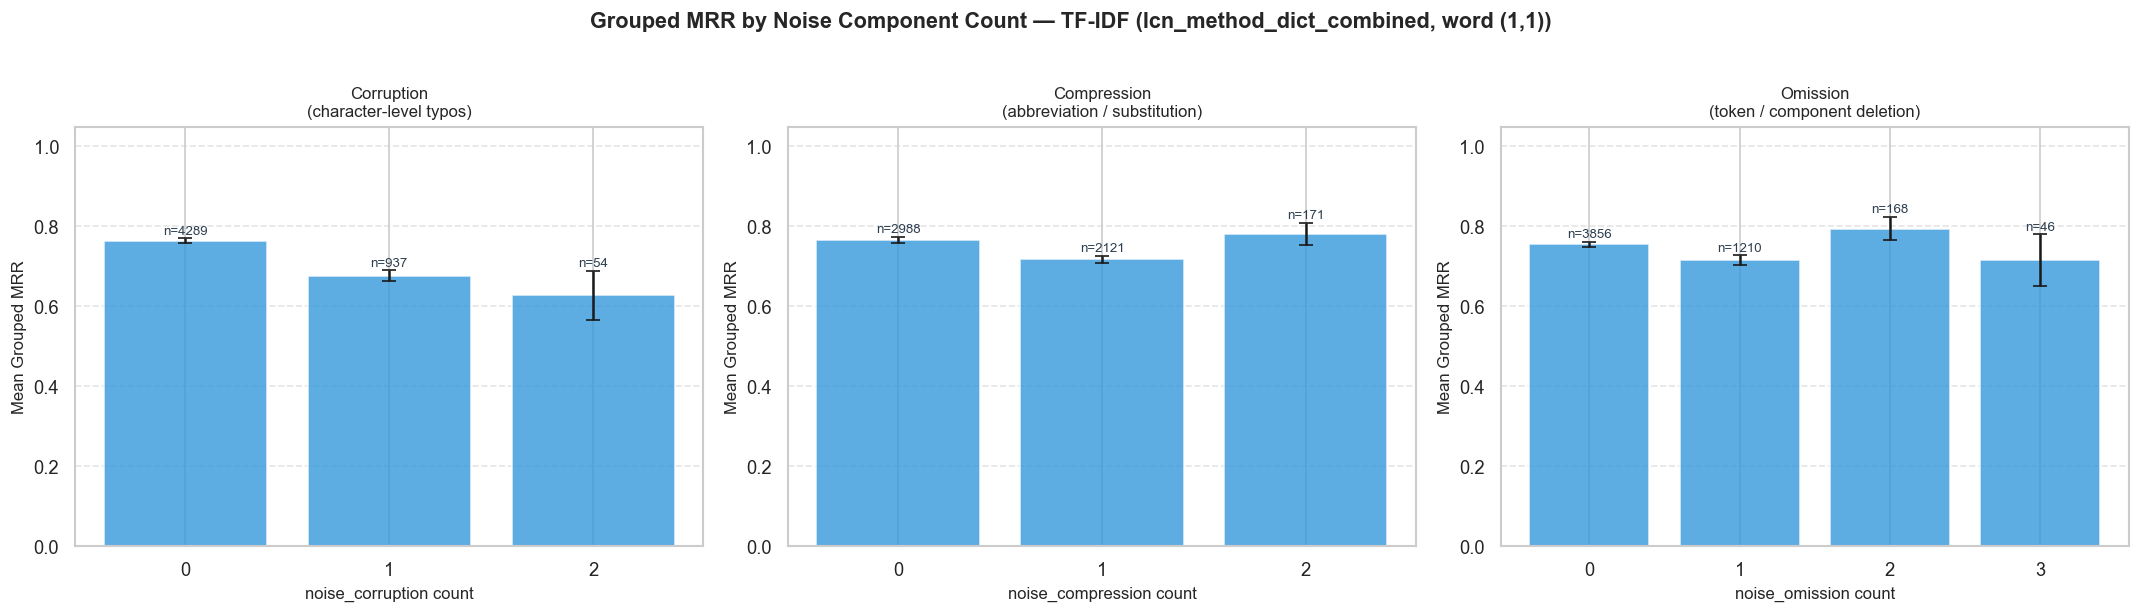

In [13]:
# Noise MRR profile — TF-IDF
fig_noise_tfidf = run_noise_analysis(
    df_tfidf_best,
    loinc,
    title_suffix="— TF-IDF (lcn_method_dict_combined, word (1,1))",
    save_path="data/results/viz_noise_profile_tfidf.png",
)
display(fig_noise_tfidf)

In [14]:
# MRR by noise level
print("Grouped MRR by noise level (TF-IDF):")
display(summarize_by_noise(df_tfidf_best))

Grouped MRR by noise level (TF-IDF):


,mrr_grouped_mean,n
noise_level,,
low,0.762375,3934
medium,0.709885,1305
high,0.510163,41


## 4. Single-Model Error Analysis — ST (PubMedBERT)

In [15]:
# Classify axis mismatches — ST
# Note: ST results use 'model_type' as the strategy column
df_st_classified = classify_axis_mismatches(df_st_best, loinc)

print("System direction summary (ST PubMedBERT, wrong top-1 predictions):")
display(system_direction_summary(df_st_classified))

System direction summary (ST PubMedBERT, wrong top-1 predictions):


mrr_correct,mrr_grouped<1 (real error),mrr_grouped=1 (absorbed)
direction_system,,
catchall_to_specific,774,94
same,928,1264
specific_to_catchall,164,234
specific_to_specific,745,279


In [16]:
print("Axis mismatch rate by coverage pattern (genuine failures only):")
display(axis_mismatch_by_coverage(df_st_classified))

Axis mismatch rate by coverage pattern (genuine failures only):


,Component,Method,System
coverage_pattern,,,
A+M+S+I,39.333333,56.666667,32.000000
A+M+S,36.842105,50.424448,34.040747
A+M+I,48.159509,48.466258,43.558282
A+M,39.194139,46.520147,42.170330
A+S+I,42.307692,53.846154,40.384615
A+S,34.317343,43.542435,48.708487
A+I,55.140187,45.794393,29.906542
A,45.833333,49.845679,47.530864
M+S+I,47.058824,47.058824,47.058824


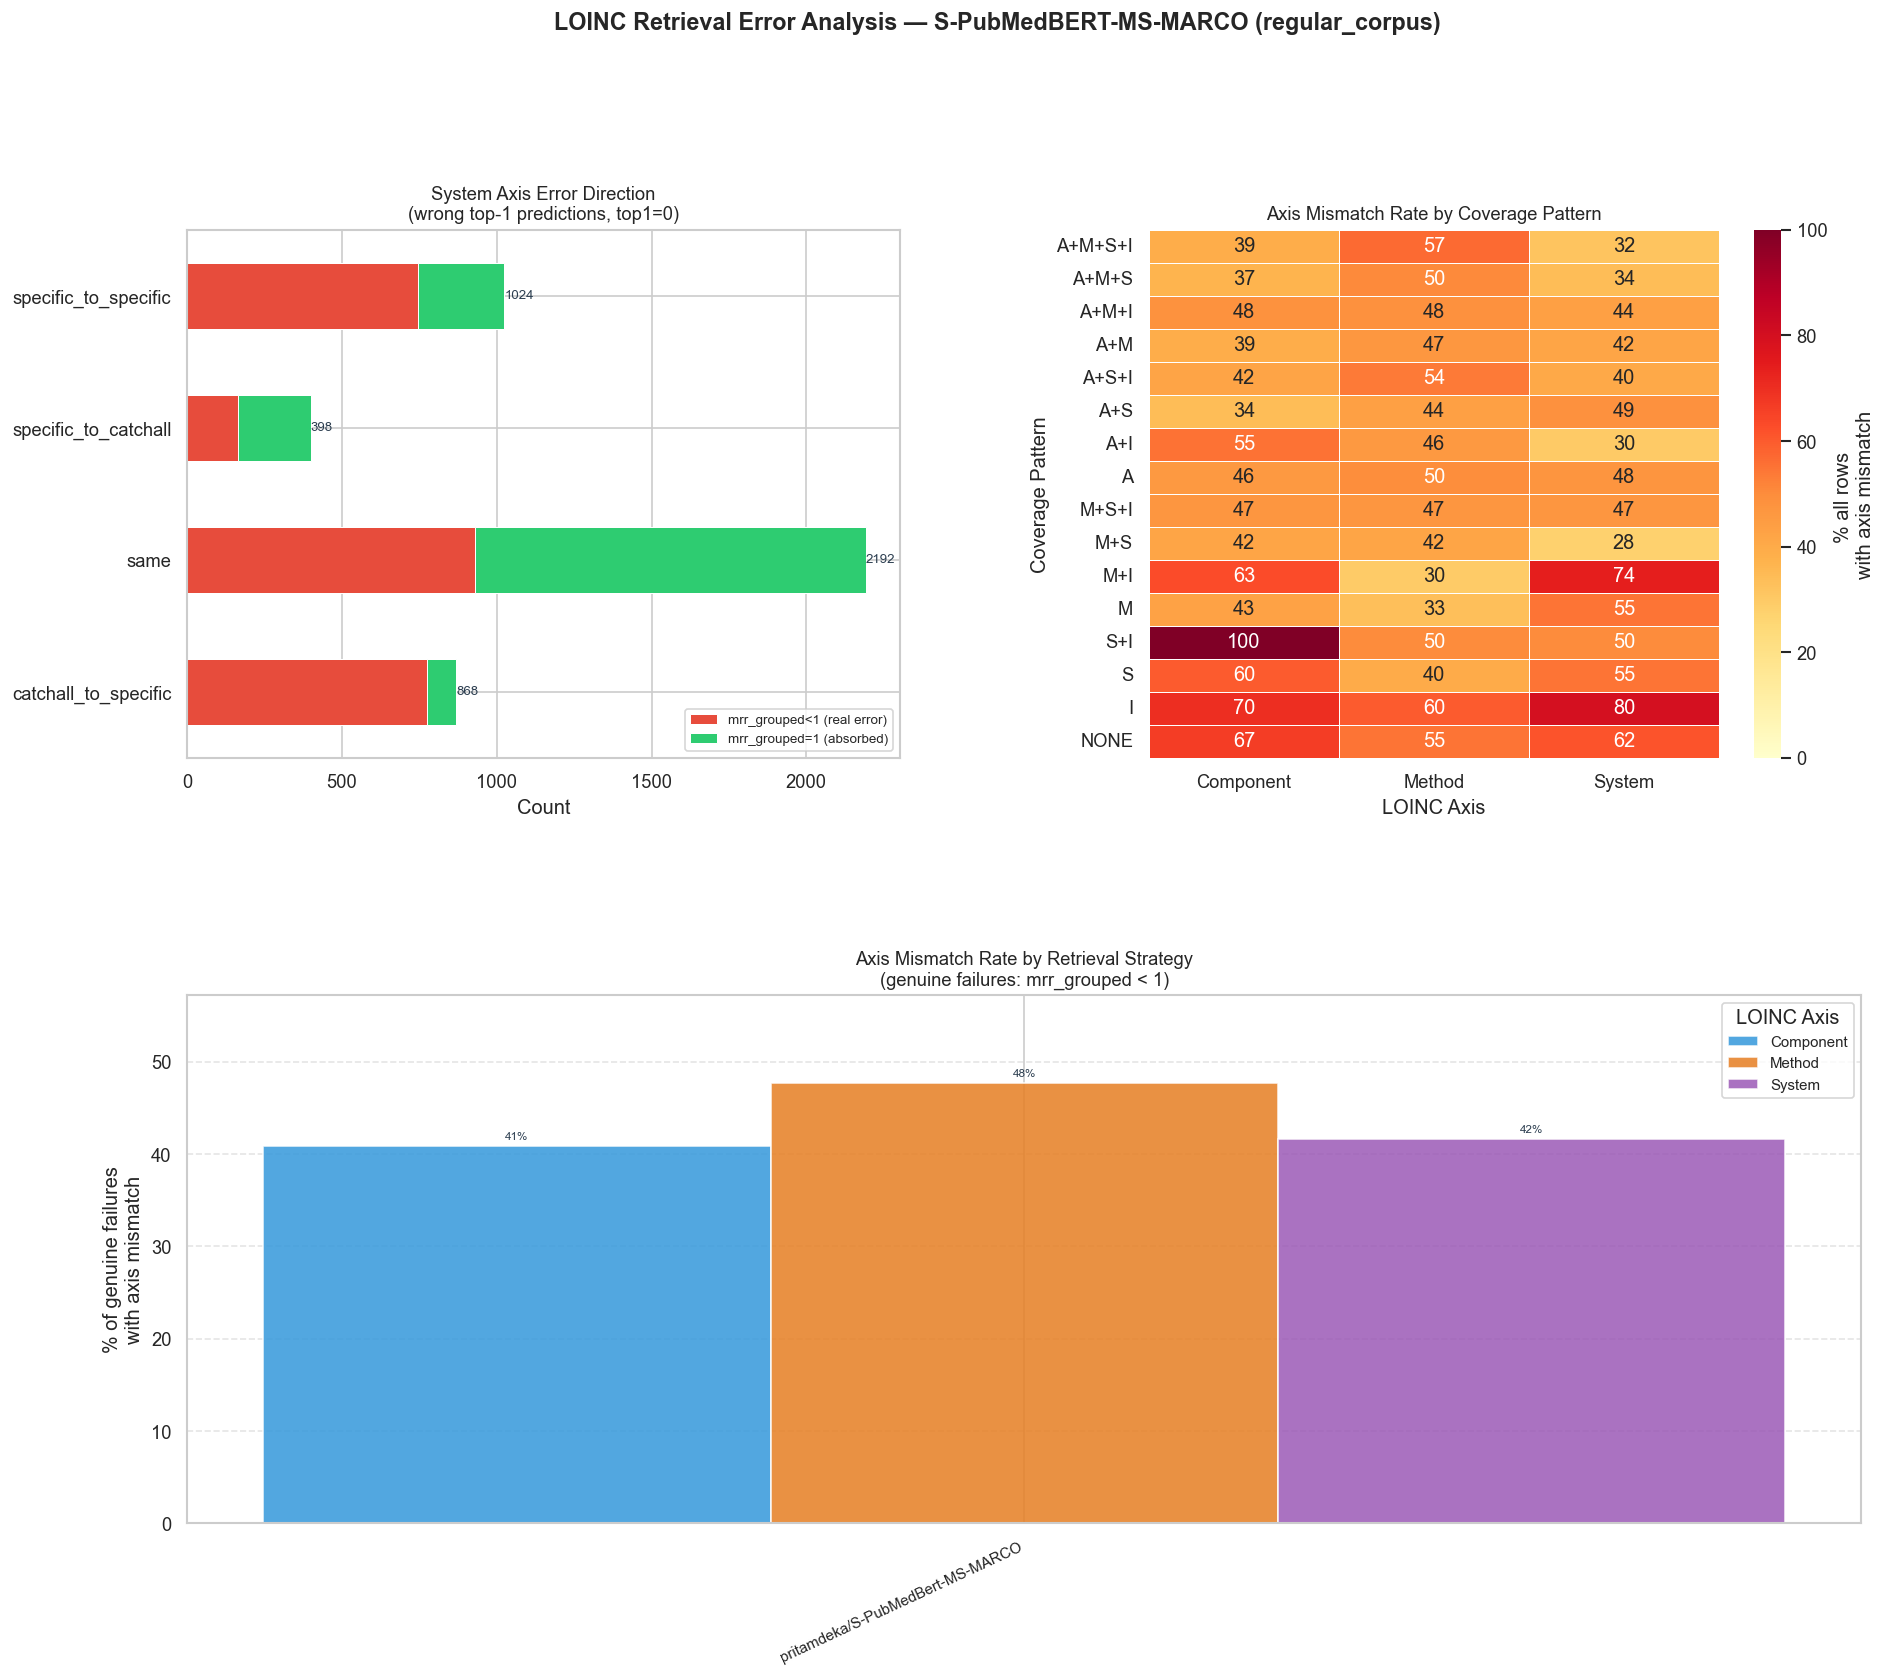

In [17]:
fig_ea_st = run_error_analysis(
    df_st_best,
    loinc,
    strategy_col="model_type",
    title_suffix="— S-PubMedBERT-MS-MARCO (regular_corpus)",
    save_path="data/results/viz_error_analysis_st.png",
)
display(fig_ea_st)

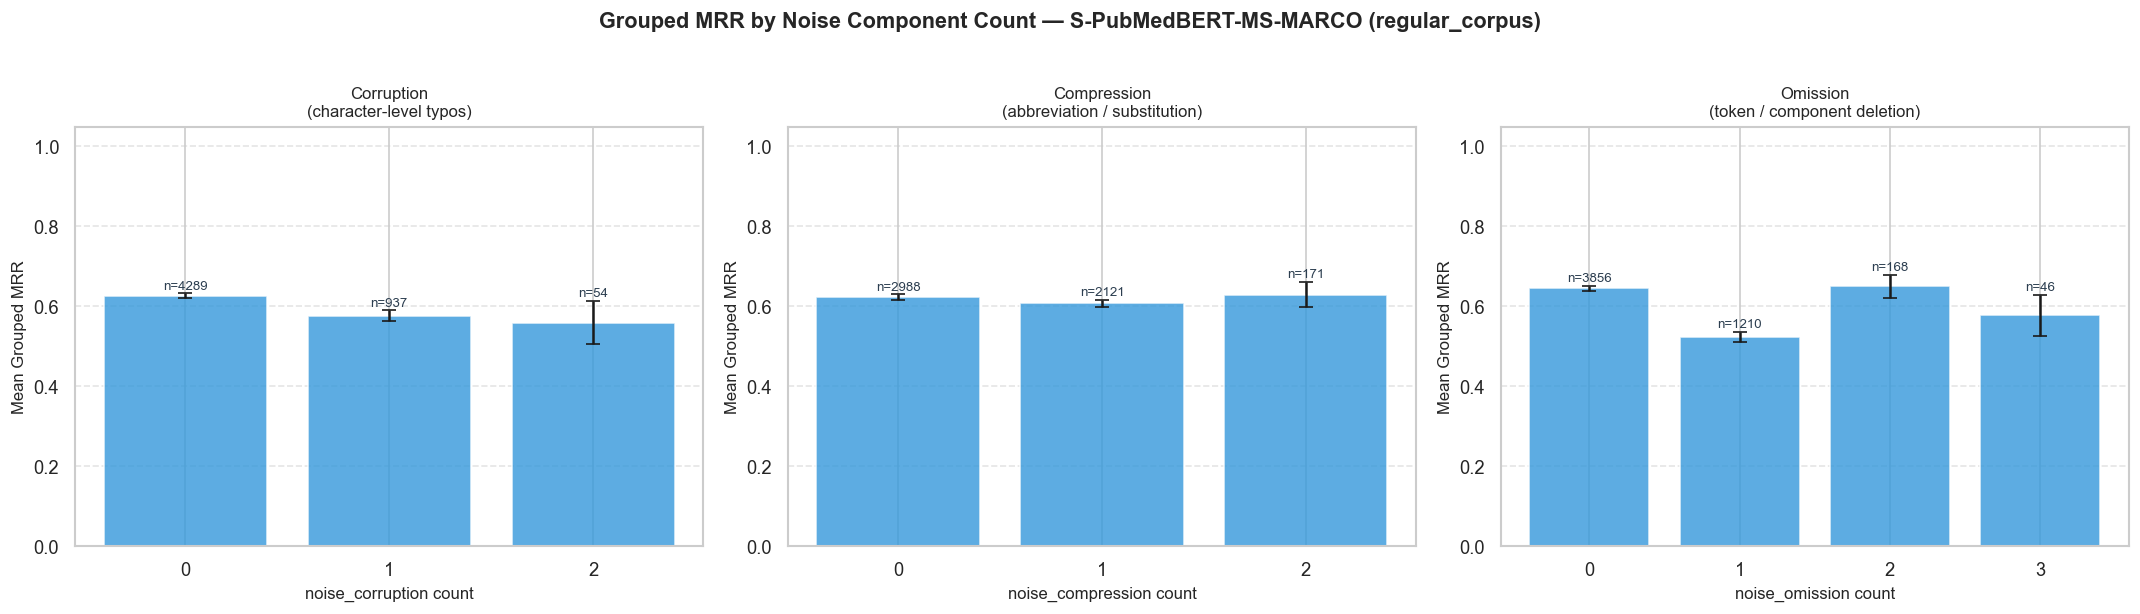

In [18]:
fig_noise_st = run_noise_analysis(
    df_st_best,
    loinc,
    title_suffix="— S-PubMedBERT-MS-MARCO (regular_corpus)",
    save_path="data/results/viz_noise_profile_st.png",
)
display(fig_noise_st)

In [19]:
print("Grouped MRR by noise level (ST):")
display(summarize_by_noise(df_st_best))

Grouped MRR by noise level (ST):


,mrr_grouped_mean,n
noise_level,,
low,0.634308,3934
medium,0.569885,1305
high,0.456911,41


## 5. Cross-Model Comparison: Coverage Pattern and Noise Dimensions

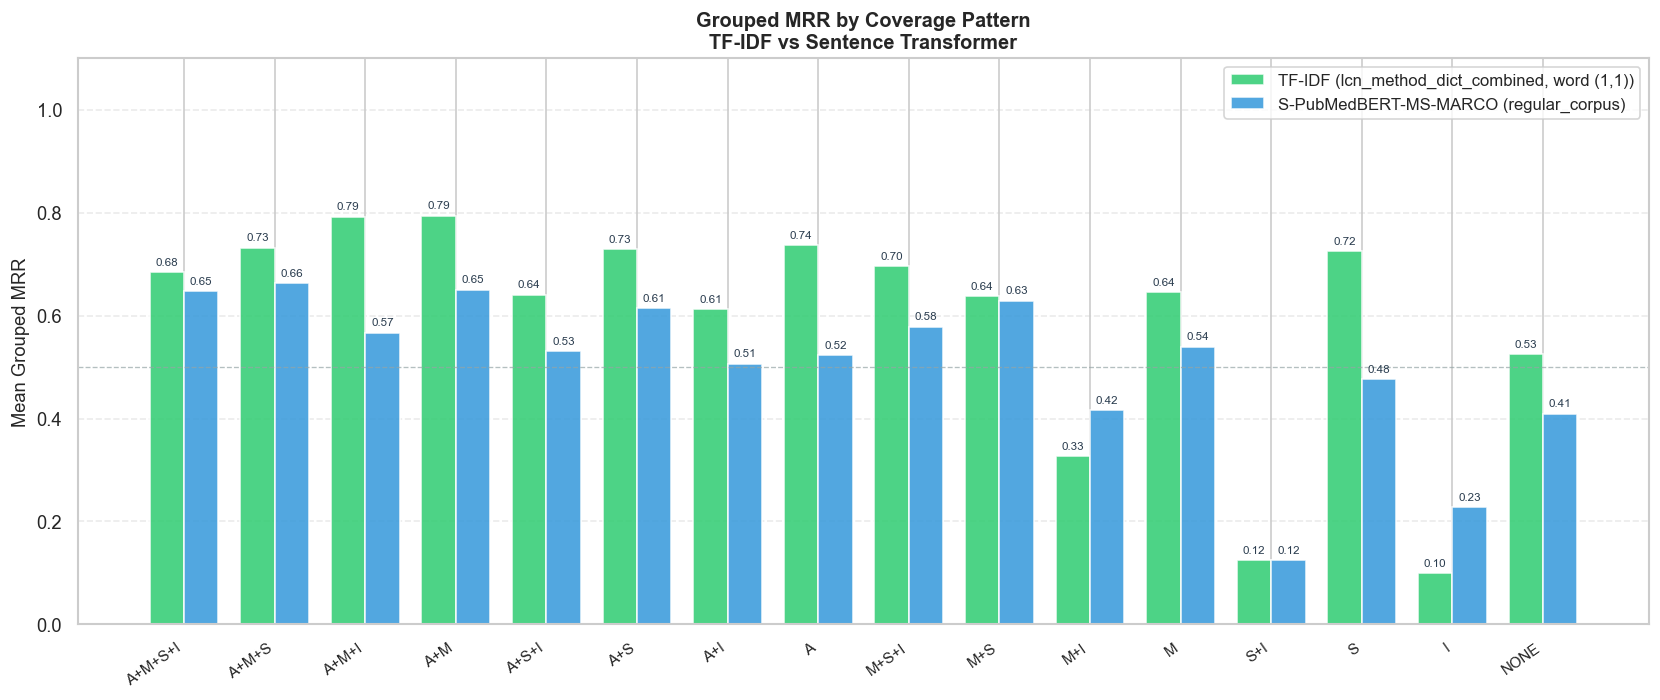

In [20]:
fig_cov, fig_noise_comp = run_model_comparison(
    df_tfidf=df_tfidf_best,
    df_st=df_st_best,
    df_loinc=loinc,
    tfidf_label="TF-IDF (lcn_method_dict_combined, word (1,1))",
    st_label="S-PubMedBERT-MS-MARCO (regular_corpus)",
    save_path_coverage="data/results/viz_comparison_by_coverage.png",
    save_path_noise="data/results/viz_comparison_by_noise.png",
)
display(fig_cov)

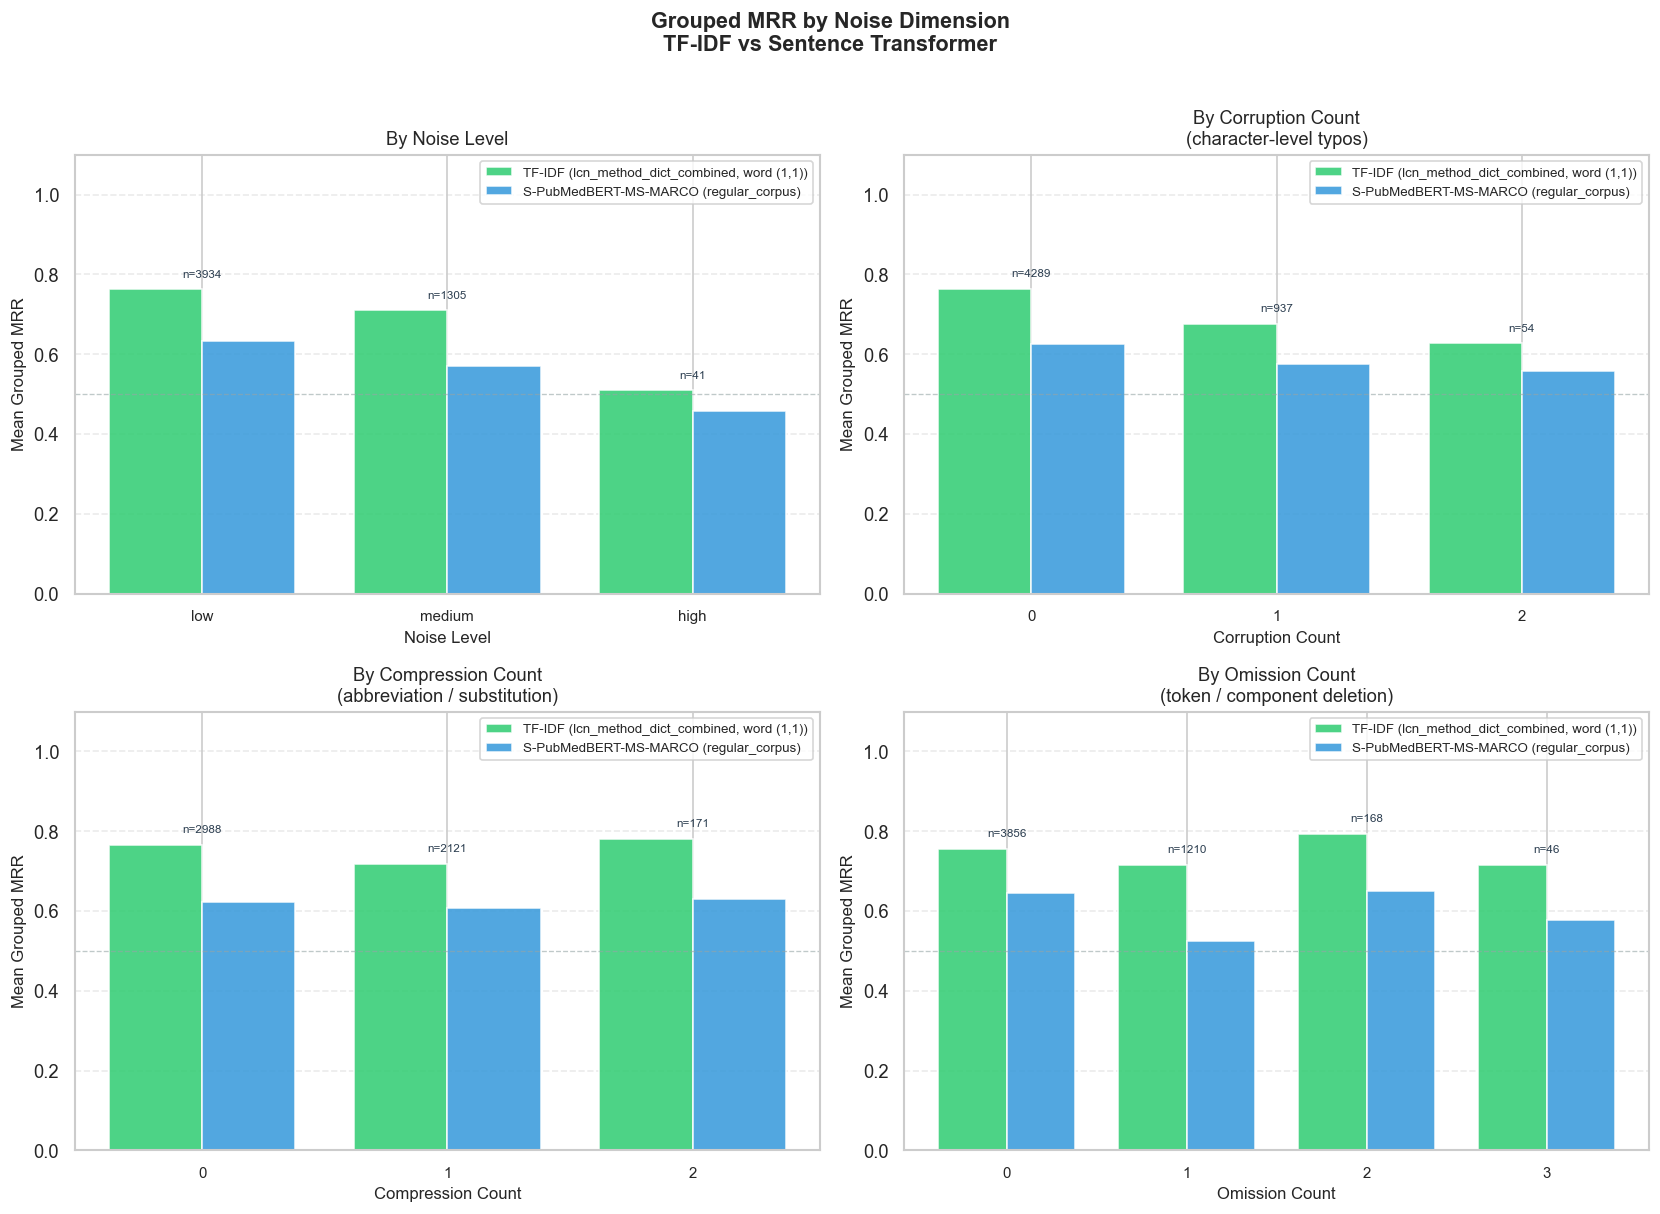

In [21]:
display(fig_noise_comp)

In [22]:
# Head-to-head summary table: key metrics side by side
metrics = ["mrr_grouped", "top1", "top3", "top5"]
summary = pd.DataFrame({
    "TF-IDF (best)": df_tfidf_best[metrics].mean(),
    "ST PubMedBERT": df_st_best[metrics].mean(),
}).T
print("Head-to-head metric summary:")
display(summary.round(4))

Head-to-head metric summary:


,mrr_grouped,top1,top3,top5
TF-IDF (best),0.7474,0.2820,0.4354,0.5277
ST PubMedBERT,0.6170,0.1511,0.3231,0.4193


In [23]:
# Per-coverage-pattern MRR: side-by-side table
tfidf_cov = df_tfidf_best.groupby("coverage_pattern")["mrr_grouped"].mean().rename("TF-IDF")
st_cov    = df_st_best.groupby("coverage_pattern")["mrr_grouped"].mean().rename("ST-PubMedBERT")
cov_compare = pd.concat([tfidf_cov, st_cov], axis=1).fillna(np.nan)
cov_compare["TF-IDF lead"] = (cov_compare["TF-IDF"] - cov_compare["ST-PubMedBERT"]).round(3)
present = [p for p in COVERAGE_ORDER if p in cov_compare.index]
display(cov_compare.reindex(present).round(3))

,TF-IDF,ST-PubMedBERT,TF-IDF lead
coverage_pattern,,,
A+M+S+I,0.684,0.648,0.037
A+M+S,0.732,0.663,0.069
A+M+I,0.792,0.567,0.225
A+M,0.794,0.650,0.144
A+S+I,0.641,0.531,0.110
A+S,0.729,0.614,0.115
A+I,0.612,0.507,0.105
A,0.737,0.524,0.213
M+S+I,0.696,0.578,0.118


In [24]:
cov_compare.to_csv("data/results/coverage_pattern_comparison.csv")

## 6. All ST Models: MRR Overview

In [25]:
# All ST models, regular corpus — grouped MRR summary
st_regular = st_all[st_all["strategy"] == "regular_corpus"].copy()
st_model_summary = (
    st_regular.groupby("model_type")["mrr_grouped"]
    .agg(["mean", "median", "std", "count"])
    .rename(columns={"mean": "mrr_grouped_mean", "median": "mrr_grouped_median"})
    .sort_values("mrr_grouped_mean", ascending=False)
)
display(st_model_summary.round(4))

,mrr_grouped_mean,mrr_grouped_median,std,count
model_type,,,,
pritamdeka/S-PubMedBert-MS-MARCO,0.6170,1.0000,0.4123,5280
sentence-transformers/all-MiniLM-L6-v2,0.5733,0.5000,0.4207,5280
neuml/pubmedbert-base-embeddings,0.4919,0.5000,0.4174,5280
sentence-transformers/msmarco-distilbert-base-v4,0.4626,0.3333,0.4361,5280
cambridgeltl/SapBERT-from-PubMedBERT-fulltext-mean-token,0.2934,0.2000,0.3470,5280
cambridgeltl/SapBERT-from-PubMedBERT-fulltext,0.2178,0.0000,0.3277,5280


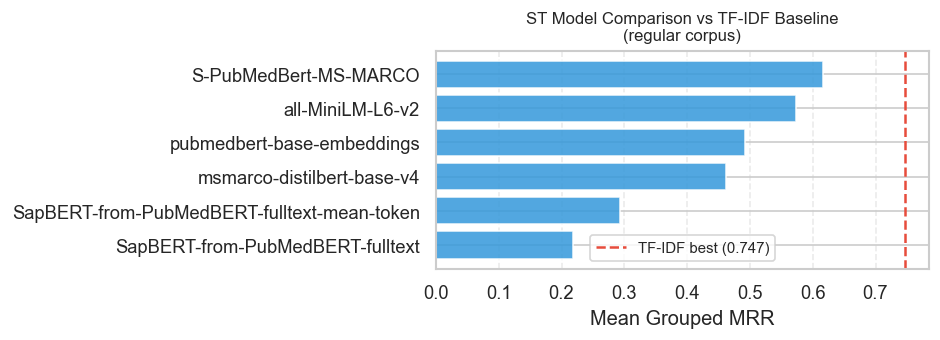

In [26]:
# Compared to TF-IDF baseline
tfidf_mrr = df_tfidf_best["mrr_grouped"].mean()
fig, ax = plt.subplots(figsize=(8, 3))
short_names = st_model_summary.index.str.split("/").str[-1]
ax.barh(
    short_names[::-1],
    st_model_summary["mrr_grouped_mean"].values[::-1],
    color="#3498db", alpha=0.85, edgecolor="white"
)
ax.axvline(tfidf_mrr, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"TF-IDF best ({tfidf_mrr:.3f})")
ax.set_xlabel("Mean Grouped MRR")
ax.set_title("ST Model Comparison vs TF-IDF Baseline\n(regular corpus)", fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("data/results/viz_st_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Noise Audit: Component-Presence Heatmaps

Three heatmaps showing how noise component counts vary by ELR component presence (`has_method`, `has_specimen`, `has_model`).

**Methodological note:** Omission count is naturally confounded with `has_method` presence — the counter increments when a method token is omitted, so higher omission correlates trivially with method absence. Compression and corruption are not confounded and provide clean signal.

In [27]:
# Load ELR simulated data for the noise audit (not in filter ablation output)
elr = pd.read_csv("data/processed/elr_simulated.csv")
print(f"ELR simulated dataset: {elr.shape[0]:,} rows")

ELR simulated dataset: 6,600 rows


In [28]:
def plot_noise_component_heatmap(df, component_col, title, figsize=(7, 3.5)):
    """
    Heatmap of mean noise_* count by component presence (0/1) × noise type.
    """
    noise_cols = ["noise_corruption", "noise_compression", "noise_omission"]
    pivot = (
        df.groupby(component_col)[noise_cols].mean()
        .rename(columns=lambda c: c.replace("noise_", "").title())
    )
    pivot.index = pivot.index.map({0: f"{component_col}=0", 1: f"{component_col}=1"})

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".2f",
        cmap="YlOrRd", linewidths=0.5,
        cbar_kws={"label": "Mean count per string"},
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Noise Type")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    return fig

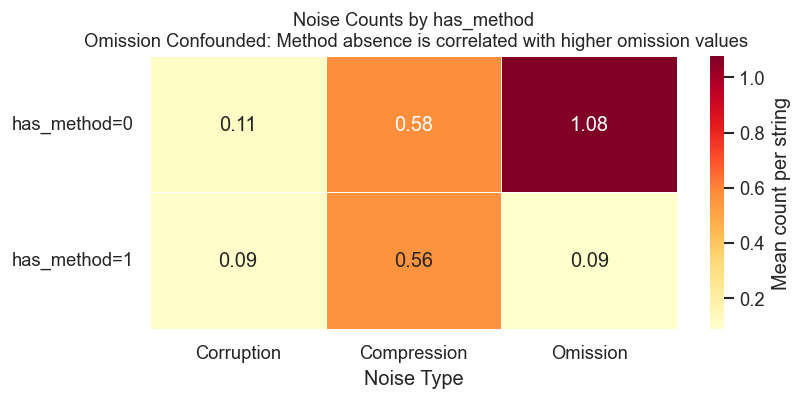

In [29]:
fig_h1 = plot_noise_component_heatmap(
    elr, "has_method",
    "Noise Counts by has_method\n Omission Confounded: Method absence is correlated with higher omission values"
)
fig_h1.savefig("data/results/viz_noise_heatmap_has_method.png", dpi=150, bbox_inches="tight")
plt.show()

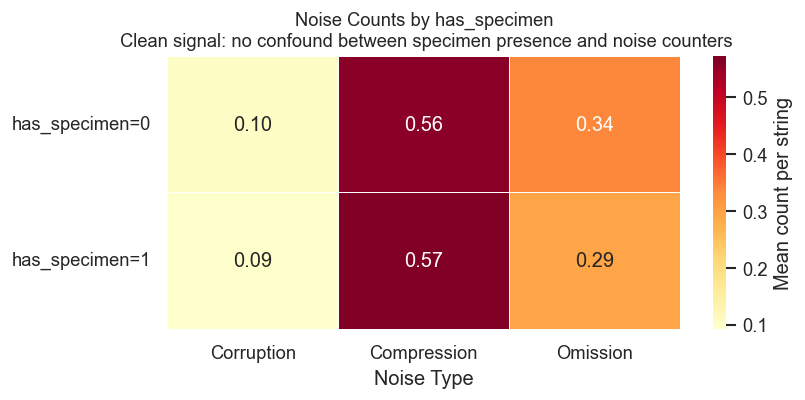

In [30]:
fig_h2 = plot_noise_component_heatmap(
    elr, "has_specimen",
    "Noise Counts by has_specimen\n Clean signal: no confound between specimen presence and noise counters"
)
fig_h2.savefig("data/results/viz_noise_heatmap_has_specimen.png", dpi=150, bbox_inches="tight")
plt.show()

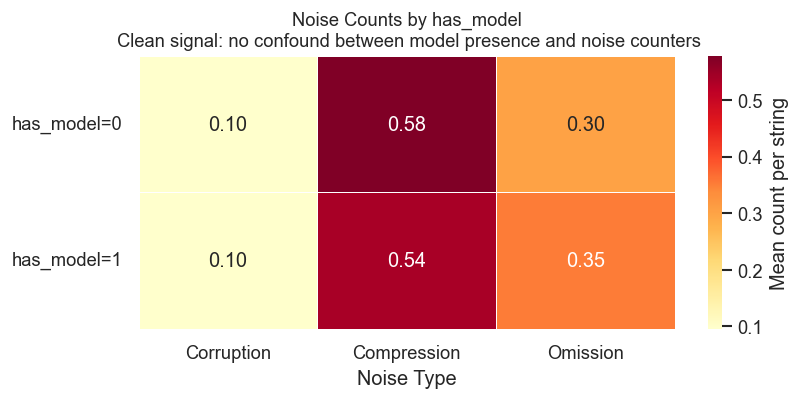

In [31]:
fig_h3 = plot_noise_component_heatmap(
    elr, "has_model",
    "Noise Counts by has_model\n Clean signal: no confound between model presence and noise counters"
)
fig_h3.savefig("data/results/viz_noise_heatmap_has_model.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Correlation check: confirm omission/has_method confound numerically
print("Correlation between noise components and has_method:")
display(
    elr[["noise_corruption", "noise_compression", "noise_omission", "has_method"]]
    .corr()[["has_method"]]
    .rename(columns={"has_method": "corr_with_has_method"})
    .round(3)
)

Correlation between noise components and has_method:


,corr_with_has_method
noise_corruption,-0.015
noise_compression,-0.011
noise_omission,-0.729
has_method,1.000
